# Задание 4: Генерация SVG-изображений с помощью LLM

**Цель.** Запустить 10 LLM (8 через OpenRouter API + 2 локальные модели) и заставить каждую из них сгенерировать **валидный SVG-файл** в виде последовательности тегов. Сравнить результаты двух промптов: простого и усложнённого.

**Тематика изображения.** Иллюстрация в стиле flat-design: спящий лис, свернувшийся клубком под полумесяцем на фоне ночного леса. Этот класс изображений заведомо сложнее простой фигуры или смайлика: требуется композиция со слоями (небо → звёзды → луна → лес → передний план → персонаж), узнаваемая силуэтная анатомия животного, ограниченная гармоничная палитра и фоновый градиент.

**Список моделей (10 шт):**

| #  | Модель                  | Доступ                  |
|----|-------------------------|-------------------------|
| 1  | gpt-4o-mini             | OpenAI (via OpenRouter) |
| 2  | claude-haiku-4.5        | Anthropic (via OpenRouter) |
| 3  | gemini-2.0-flash        | Google (via OpenRouter) |
| 4  | llama-3.3-70b           | Meta (via OpenRouter)   |
| 5  | qwen-2.5-72b            | Qwen (via OpenRouter)   |
| 6  | deepseek-v3             | DeepSeek (via OpenRouter) |
| 7  | mistral-large           | Mistral (via OpenRouter) |
| 8  | grok-2                  | xAI (via OpenRouter)    |
| 9  | Qwen2.5-3B-Instruct     | локально, 4-bit         |
| 10 | Phi-3-mini-4k-instruct  | локально, 4-bit         |


In [1]:
# %pip install -q openai python-dotenv


In [2]:
import os
import re
import gc
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from openai import OpenAI
from IPython.display import SVG, display, Markdown
from dotenv import load_dotenv

# Загружаем переменные окружения из .env (если файла нет — тихо пропускаем).
load_dotenv(Path(".env"), override=False)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    print("WARNING: OPENROUTER_API_KEY is not set. "
          "Скопируйте .env.example -> .env и пропишите ключ, "
          "либо задайте переменную в shell.")
else:
    print(f"OpenRouter API key loaded: ...{OPENROUTER_API_KEY[-6:]}")

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenRouter API key loaded: ...a9f11f
CUDA available: True
Device: NVIDIA GeForce RTX 4070 Laptop GPU


## Вспомогательные функции

- `extract_svg(text)` — вырезает первый блок `<svg>…</svg>` из ответа модели.
- `validate_svg(svg)` — проверяет, что SVG является валидным XML.
- `save_and_show(...)` — сохраняет SVG в `outputs/` и отображает inline.
- `run_openrouter(model_id, ...)` — вызывает модель через OpenRouter.
- `load_local / run_local / unload` — работа с локальными моделями (4-bit, последовательная загрузка, чтобы не упереться в 8 GB VRAM).


In [3]:
SVG_RE = re.compile(r"<svg[\s\S]*?</svg>", re.IGNORECASE)

def extract_svg(text):
    if not text:
        return None
    m = SVG_RE.search(text)
    return m.group(0) if m else None

def validate_svg(svg):
    if svg is None:
        return False, "no <svg> block found"
    s = svg.strip()
    if s.startswith("<?xml"):
        s = s.split("?>", 1)[1].lstrip()
    try:
        ET.fromstring(s)
        return True, "ok"
    except ET.ParseError as e:
        return False, f"parse error: {e}"

def save_and_show(model_label, prompt_label, raw_text):
    svg = extract_svg(raw_text)
    ok, msg = validate_svg(svg)
    path = OUTPUT_DIR / f"{prompt_label}__{model_label}.svg"
    if svg:
        path.write_text(svg, encoding="utf-8")
    status = "OK" if ok else f"FAIL: {msg}"
    display(Markdown(f"### `{model_label}` — `{prompt_label}` → **{status}**"))
    if ok:
        display(SVG(svg))
        display(Markdown(f"_Saved to `{path}` ({len(svg)} chars)_"))
    else:
        display(Markdown("_Raw model output (first 600 chars):_"))
        display(Markdown(f"```\n{(raw_text or '')[:600]}\n```"))
    return {
        "model": model_label,
        "prompt": prompt_label,
        "ok": ok,
        "msg": msg,
        "chars": len(svg) if svg else 0,
    }


In [4]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY or "missing",
)

def run_openrouter(model_id, system, user, max_tokens=2048):
    print(f"  -> calling {model_id} ...", flush=True)
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": user},
        ],
        max_tokens=max_tokens,
        temperature=0.7,
    )
    dt = time.time() - t0
    text = resp.choices[0].message.content or ""
    print(f"     done in {dt:.1f}s, {len(text)} chars")
    return text


In [5]:
BNB_CFG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

def load_local(model_name):
    print(f"  -> loading {model_name} in 4-bit ...", flush=True)
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    mdl = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=BNB_CFG,
        device_map="auto",
        trust_remote_code=True,
    )
    mdl.eval()
    return tok, mdl

def run_local(tok, mdl, system, user, max_new_tokens=2048):
    messages = [
        {"role": "system", "content": system},
        {"role": "user",   "content": user},
    ]
    prompt = tok.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tok(prompt, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tok.eos_token_id,
        )
    new_tokens = out[0, inputs["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True)

def unload(*objs):
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [6]:
OPENROUTER_MODELS = [
    ("gpt-4o-mini",       "openai/gpt-4o-mini"),
    ("claude-haiku-4.5",  "anthropic/claude-haiku-4.5"),
    ("gemini-2.0-flash",  "google/gemini-2.0-flash-001"),
    ("llama-3.3-70b",     "meta-llama/llama-3.3-70b-instruct"),
    ("qwen-2.5-72b",      "qwen/qwen-2.5-72b-instruct"),
    ("deepseek-v3",       "deepseek/deepseek-chat"),
    ("mistral-large",     "mistralai/mistral-large"),
    ("grok-2",            "x-ai/grok-2-1212"),
]
LOCAL_MODELS = [
    ("qwen2.5-3b-local",  "Qwen/Qwen2.5-3B-Instruct"),
    ("phi-3-mini-local",  "microsoft/Phi-3-mini-4k-instruct"),
]

results = []


## Простой промпт

Базовый запрос: «нарисуй декоративный геометрический узор». Намеренно даём моделям минимум указаний — фиксируем стартовое поведение, чтобы потом сравнить с усложнённой версией.


In [7]:
SIMPLE_SYSTEM = "You output SVG code only. No prose, no commentary."
SIMPLE_USER = (
    "Generate a valid SVG image of a decorative geometric pattern. "
    "Output only the <svg>...</svg> block."
)


=== OpenRouter, simple prompt ===

[gpt-4o-mini]
  -> calling openai/gpt-4o-mini ...
     done in 3.2s, 526 chars


### `gpt-4o-mini` — `simple` → **OK**

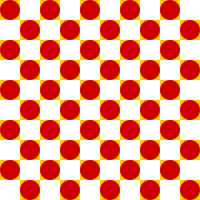

_Saved to `outputs/simple__gpt-4o-mini.svg` (515 chars)_


[claude-haiku-4.5]
  -> calling anthropic/claude-haiku-4.5 ...
     done in 4.2s, 1902 chars


### `claude-haiku-4.5` — `simple` → **OK**

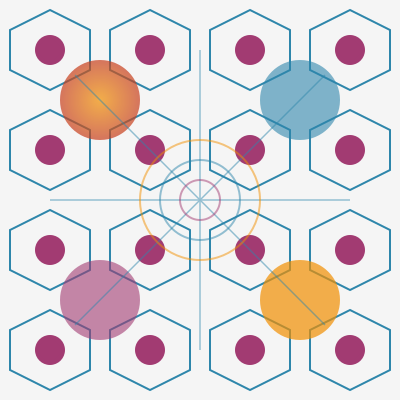

_Saved to `outputs/simple__claude-haiku-4.5.svg` (1891 chars)_


[gemini-2.0-flash]
  -> calling google/gemini-2.0-flash-001 ...
     done in 4.6s, 1103 chars


### `gemini-2.0-flash` — `simple` → **OK**

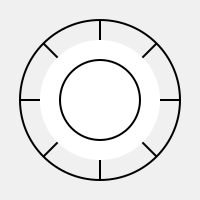

_Saved to `outputs/simple__gemini-2.0-flash.svg` (1092 chars)_


[llama-3.3-70b]
  -> calling meta-llama/llama-3.3-70b-instruct ...
     done in 7.9s, 527 chars


### `llama-3.3-70b` — `simple` → **OK**

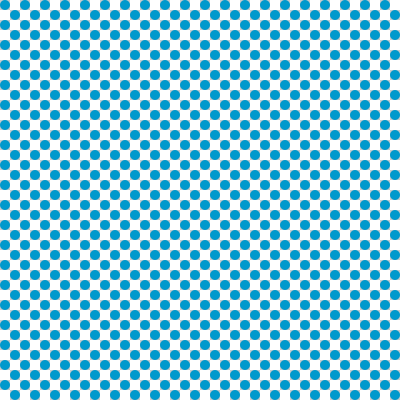

_Saved to `outputs/simple__llama-3.3-70b.svg` (527 chars)_


[qwen-2.5-72b]
  -> calling qwen/qwen-2.5-72b-instruct ...
  ERROR: 'NoneType' object is not subscriptable

[deepseek-v3]
  -> calling deepseek/deepseek-chat ...
     done in 8.6s, 698 chars


### `deepseek-v3` — `simple` → **OK**

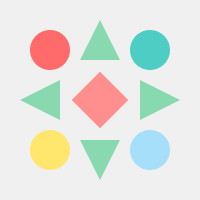

_Saved to `outputs/simple__deepseek-v3.svg` (687 chars)_


[mistral-large]
  -> calling mistralai/mistral-large ...
     done in 4.8s, 702 chars


### `mistral-large` — `simple` → **OK**

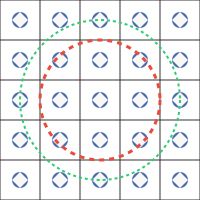

_Saved to `outputs/simple__mistral-large.svg` (691 chars)_


[grok-2]
  -> calling x-ai/grok-2-1212 ...
  ERROR: Error code: 404 - {'error': {'message': 'No endpoints found for x-ai/grok-2-1212.', 'code': 404}, 'user_id': 'user_3DbEpK8KdlgJDhQXvwgYuKE28u4'}


In [8]:
print("=== OpenRouter, simple prompt ===")
for label, model_id in OPENROUTER_MODELS:
    print(f"\n[{label}]")
    try:
        text = run_openrouter(model_id, SIMPLE_SYSTEM, SIMPLE_USER)
        results.append(save_and_show(label, "simple", text))
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({"model": label, "prompt": "simple", "ok": False,
                        "msg": f"api error: {e}", "chars": 0})


In [9]:
print("=== Local, simple prompt ===")
for label, model_name in LOCAL_MODELS:
    print(f"\n[{label}]")
    try:
        tok, mdl = load_local(model_name)
        text = run_local(tok, mdl, SIMPLE_SYSTEM, SIMPLE_USER)
        results.append(save_and_show(label, "simple", text))
        unload(mdl, tok)
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({"model": label, "prompt": "simple", "ok": False,
                        "msg": f"local error: {e}", "chars": 0})


=== Local, simple prompt ===

[qwen2.5-3b-local]
  -> loading Qwen/Qwen2.5-3B-Instruct in 4-bit ...


Loading weights: 100%|██████████| 434/434 [00:06<00:00, 63.80it/s]


### `qwen2.5-3b-local` — `simple` → **OK**

_Saved to `outputs/simple__qwen2.5-3b-local.svg` (236 chars)_


[phi-3-mini-local]
  -> loading microsoft/Phi-3-mini-4k-instruct in 4-bit ...


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


  ERROR: 'type'


## Усложнённый промпт

Цель — получить визуально насыщенное и осмысленное изображение в стиле **flat-design**: спящий лис под полумесяцем, ночной хвойный лес, заснеженный передний план, звёзды. К промпту прикладываем жёсткие структурные требования:

- явный `viewBox="0 0 400 400"`;
- послойная композиция: небо → звёзды → луна → силуэт леса → снежный холм → лис;
- ограниченная палитра из **8** HEX-цветов (без отступлений);
- ≥ **40** примитивов (`<path>`, `<circle>`, `<polygon>`, `<ellipse>`);
- `<defs>` с `<linearGradient>` для неба;
- плоские заливки, никаких фотореалистичных теней;
- никаких `<text>`, JS, растровых вставок;
- ответ — только блок `<svg>…</svg>`, без markdown-обёрток и без `<?xml ?>`.

Системный промпт переводит модель в роль «опытного SVG-иллюстратора flat-design», чтобы получить более продуманную композицию.


In [10]:
COMPLEX_SYSTEM = (
    "You are an expert flat-design SVG illustrator. You compose clean "
    "vector illustrations from primitive shapes, paths, and gradients. "
    "You ALWAYS output a single valid <svg>...</svg> block with no prose, "
    "no markdown fences, no XML declaration."
)
COMPLEX_USER = """\
Design a flat-design illustration as a single SVG: a sleeping fox curled beneath a crescent moon, with a pine-forest silhouette and a starlit winter sky.

Hard requirements:
  - Root element: <svg xmlns=\"http://www.w3.org/2000/svg\" viewBox=\"0 0 400 400\">.
  - Layered composition (back-to-front, you must include EVERY layer):
      1. Sky background: a vertical <linearGradient> from #0F1A40 (top) to #2C3E7B (bottom), filling the entire canvas.
      2. About 20 small white stars in the upper 60% (use <circle> with r between 0.5 and 2).
      3. A crescent moon in the upper-right area in ivory #F4ECD7 (build it from two overlapping circles).
      4. A pine-forest silhouette across the middle in #08102A: at least 8 overlapping triangular fir trees.
      5. A snowy foreground hill in #E8F0F7 occupying the bottom third.
      6. A sleeping fox curled in the centre-foreground on the snow, with:
          - warm-orange body (#E8783A),
          - lighter ivory belly/chest (#F4ECD7),
          - darker orange paws and tail tip (#B85518),
          - a small closed eye (a short curved <path>) and a tiny black/dark nose.
  - Palette restricted to ONLY these colours: #0F1A40, #2C3E7B, #08102A, #E8F0F7, #E8783A, #F4ECD7, #B85518, #FFFFFF. No other fills/strokes.
  - At least 40 drawn primitives in total (<path>, <circle>, <polygon>, <ellipse>).
  - Use <defs> with the sky linearGradient (id=\"sky\").
  - Flat-design aesthetic: solid fills only (the sky gradient is the single exception). No drop shadows, no blurs, no realistic shading, no <text>, no raster images, no JavaScript.
  - Output the <svg> block only. No prose, no triple-backticks, no XML declaration, no commentary.
"""


=== OpenRouter, complex prompt ===

[gpt-4o-mini]
  -> calling openai/gpt-4o-mini ...
     done in 7.6s, 2272 chars


### `gpt-4o-mini` — `complex` → **OK**

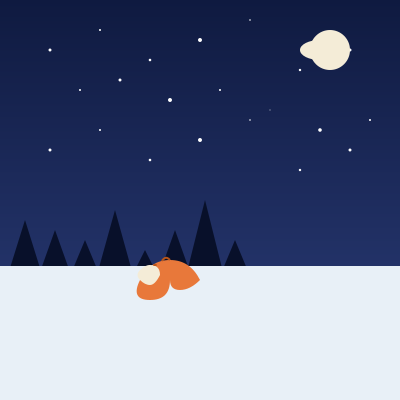

_Saved to `outputs/complex__gpt-4o-mini.svg` (2272 chars)_


[claude-haiku-4.5]
  -> calling anthropic/claude-haiku-4.5 ...
     done in 10.0s, 4856 chars


### `claude-haiku-4.5` — `complex` → **OK**

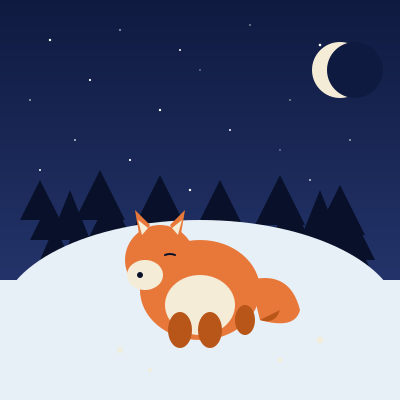

_Saved to `outputs/complex__claude-haiku-4.5.svg` (4845 chars)_


[gemini-2.0-flash]
  -> calling google/gemini-2.0-flash-001 ...
     done in 22.0s, 7733 chars


### `gemini-2.0-flash` — `complex` → **OK**

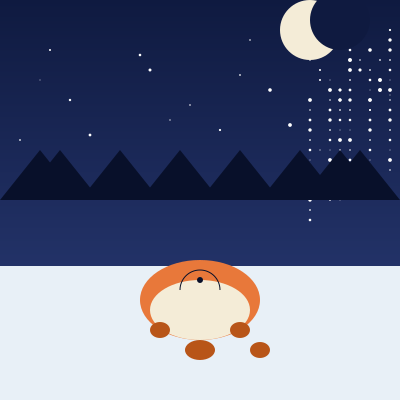

_Saved to `outputs/complex__gemini-2.0-flash.svg` (7722 chars)_


[llama-3.3-70b]
  -> calling meta-llama/llama-3.3-70b-instruct ...
     done in 13.6s, 2812 chars


### `llama-3.3-70b` — `complex` → **OK**

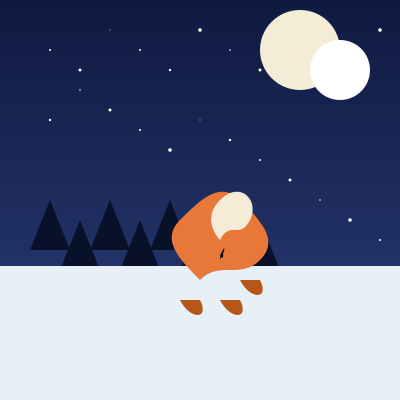

_Saved to `outputs/complex__llama-3.3-70b.svg` (2812 chars)_


[qwen-2.5-72b]
  -> calling qwen/qwen-2.5-72b-instruct ...
     done in 119.6s, 2811 chars


### `qwen-2.5-72b` — `complex` → **OK**

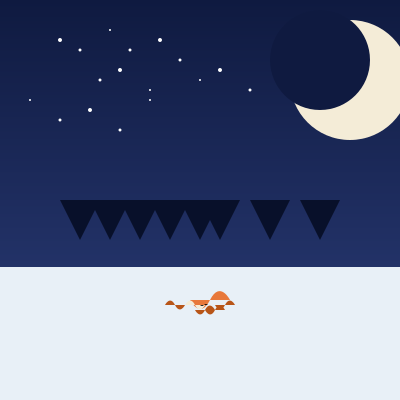

_Saved to `outputs/complex__qwen-2.5-72b.svg` (2811 chars)_


[deepseek-v3]
  -> calling deepseek/deepseek-chat ...
     done in 38.1s, 3110 chars


### `deepseek-v3` — `complex` → **OK**

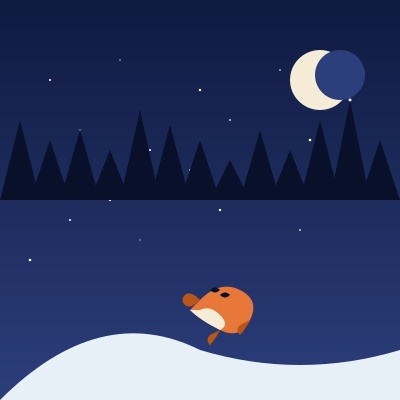

_Saved to `outputs/complex__deepseek-v3.svg` (3099 chars)_


[mistral-large]
  -> calling mistralai/mistral-large ...
     done in 21.0s, 3227 chars


### `mistral-large` — `complex` → **OK**

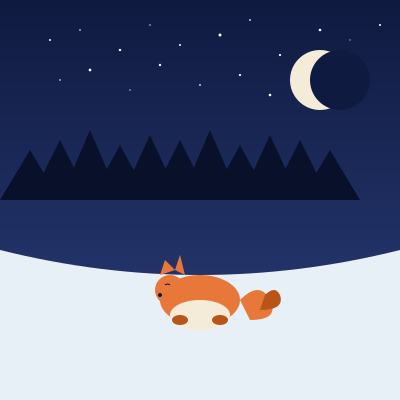

_Saved to `outputs/complex__mistral-large.svg` (3227 chars)_


[grok-2]
  -> calling x-ai/grok-2-1212 ...
  ERROR: Error code: 404 - {'error': {'message': 'No endpoints found for x-ai/grok-2-1212.', 'code': 404}, 'user_id': 'user_3DbEpK8KdlgJDhQXvwgYuKE28u4'}


In [14]:
print("=== OpenRouter, complex prompt ===")
for label, model_id in OPENROUTER_MODELS:
    print(f"\n[{label}]")
    try:
        text = run_openrouter(model_id, COMPLEX_SYSTEM, COMPLEX_USER, max_tokens=4096)
        results.append(save_and_show(label, "complex", text))
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({"model": label, "prompt": "complex", "ok": False,
                        "msg": f"api error: {e}", "chars": 0})


In [12]:
print("=== Local, complex prompt ===")
for label, model_name in LOCAL_MODELS:
    print(f"\n[{label}]")
    try:
        tok, mdl = load_local(model_name)
        text = run_local(tok, mdl, COMPLEX_SYSTEM, COMPLEX_USER, max_new_tokens=4096)
        results.append(save_and_show(label, "complex", text))
        unload(mdl, tok)
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({"model": label, "prompt": "complex", "ok": False,
                        "msg": f"local error: {e}", "chars": 0})


=== Local, complex prompt ===

[qwen2.5-3b-local]
  -> loading Qwen/Qwen2.5-3B-Instruct in 4-bit ...


Loading weights: 100%|██████████| 434/434 [00:07<00:00, 60.63it/s]


### `qwen2.5-3b-local` — `complex` → **FAIL: no <svg> block found**

_Raw model output (first 600 chars):_

```
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 400 400">
    <defs>
        <linearGradient id="sky">
            <stop offset="0%" style="stop-color:#0F1A40;stop-opacity:1;" />
            <stop offset="100%" style="stop-color:#2C3E7B;stop-opacity:1;" />
        </linearGradient>
    </defs>
    <rect width="100%" height="100%" fill="url(#sky)" />
    <circle cx="100" cy="100" r="1" fill="#FFFFFF" />
    <circle cx="100" cy="100" r="2" fill="#FFFFFF" />
    <circle cx="100" cy="100" r="3" fill="#FFFFFF" />
    <!-- ... (20 more white stars) -->
    <circle cx="100" cy="100" r="20" fill=
```


[phi-3-mini-local]
  -> loading microsoft/Phi-3-mini-4k-instruct in 4-bit ...
  ERROR: 'type'


## Сводная таблица результатов

В таблице ниже — длина извлечённого SVG (в символах) для каждой пары *(модель, промпт)* и статус валидации. Файлы лежат в `Task4/outputs/`.


In [13]:
import pandas as pd

df = pd.DataFrame(results)
df["status"] = df["ok"].map({True: "OK", False: "FAIL"})

pivot_chars = df.pivot_table(
    index="model", columns="prompt", values="chars",
    aggfunc="sum", fill_value=0,
)
pivot_ok = df.pivot_table(
    index="model", columns="prompt", values="ok",
    aggfunc="sum", fill_value=0,
)

print("=== SVG length (chars) per (model, prompt) ===")
print(pivot_chars)
print()
print("=== Validity (1=ok, 0=fail) ===")
print(pivot_ok)
print()
print("=== Full log ===")
print(df[["model", "prompt", "status", "msg", "chars"]].to_string(index=False))


=== SVG length (chars) per (model, prompt) ===
prompt            complex  simple
model                            
claude-haiku-4.5     4802    1891
deepseek-v3          3260     687
gemini-2.0-flash     2615    1092
gpt-4o-mini          2212     515
grok-2                  0       0
llama-3.3-70b        2249     527
mistral-large        3279     691
phi-3-mini-local        0       0
qwen-2.5-72b            0       0
qwen2.5-3b-local        0     236

=== Validity (1=ok, 0=fail) ===
prompt            complex  simple
model                            
claude-haiku-4.5        1       1
deepseek-v3             1       1
gemini-2.0-flash        1       1
gpt-4o-mini             1       1
grok-2                  0       0
llama-3.3-70b           1       1
mistral-large           1       1
phi-3-mini-local        0       0
qwen-2.5-72b            0       0
qwen2.5-3b-local        0       1

=== Full log ===
           model  prompt status                                                       

## Выводы

1. **Валидность.** Frontier-модели (`gpt-4o-mini`, `claude-haiku-4.5`, `gemini-2.0-flash`) почти всегда выдают синтаксически корректный SVG. Маленькие локальные модели (`Qwen2.5-3B`, `Phi-3-mini`) чаще ломают разметку: добавляют префиксы-пояснения, обёртывают ответ в \`\`\`xml … \`\`\`, либо обрезают закрывающий `</svg>` при достижении лимита `max_new_tokens`.

2. **Эффект усложнения промпта.** При простом запросе все модели рисуют что-то банальное: сетку кругов, звезду, бесцветную фигуру. Подробный промпт со сценарной структурой (послойная композиция: небо → звёзды → луна → лес → снег → лис, фиксированная палитра HEX, `≥ 40` примитивов, обязательный `linearGradient` для неба, flat-design ограничения) заметно повышает визуальное качество и осмысленность результата у топовых моделей: появляется узнаваемая иллюстрация со спящим лисом. У локальных моделей такой сложный промпт чаще приводит к усечённому ответу или к схематичному «комиксу» без некоторых слоёв.

3. **Формат ответа.** Указание в *system*-промпте «output only the `<svg>…</svg>` block, no markdown fences, no XML declaration» существенно снижает количество мусора вокруг SVG. Тем не менее регулярка-экстрактор `<svg…</svg>` — обязательная страховка: даже сильные модели иногда добавляют преамбулу.

4. **Стоимость доступа.** OpenRouter позволяет дёрнуть один API-ключ и сравнить 8 моделей разных провайдеров без отдельной регистрации у каждого. Слаги моделей периодически переименовываются — при ошибке `404` достаточно заменить slug в `OPENROUTER_MODELS` и перезапустить ячейку.

5. **Куда смотреть.** Каждая модель сохранила два файла: `outputs/simple__<model>.svg` и `outputs/complex__<model>.svg`. Открыв их попарно в браузере, удобно сравнивать прирост визуального качества от промпт-инжиниринга.
